<a href="https://colab.research.google.com/github/palakbhatt1/fuel-price-prediction-india-regression-models/blob/main/fuel_price_prediction_india_regression_models.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Predicting Petrol Prices in India
### Final Machine Learning Project (30 Marks)

**Objective:** Build and compare different machine learning regression models to predict petrol prices in India using economic indicators like Brent oil prices, USD-INR exchange rates, and excise tax data.

We'll use: Linear Regression, Decision Tree Regressor, Random Forest, and Support Vector Regressor.

Data Source: [GitHub Dataset](https://raw.githubusercontent.com/Harshs-06/Datasets_MachineLearning/refs/heads/main/Final_Combined_Data_With_Excise.csv)

In [ ]:
# Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor, plot_tree
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from sklearn.metrics import mean_squared_error, r2_score
import warnings
warnings.filterwarnings('ignore')
sns.set_style('whitegrid')

In [ ]:
# Load and Preview Dataset
df = pd.read_csv("https://raw.githubusercontent.com/Harshs-06/Datasets_MachineLearning/refs/heads/main/Final_Combined_Data_With_Excise.csv")
df.head()

,Date,Petrol_Price_INR,PriceChange,ChangeDirection,USD_INR_Price,USD_INR_Open,USD_INR_High,USD_INR_Low,USD_INR_Vol,USD_INR_Change_Percent,Brent_Oil_Price_USD,Brent_Oil_Open,Brent_Oil_High,Brent_Oil_Low,Brent_Oil_Vol,Brent_Oil_Change_Percent,Excise_Tax_Type,Excise_Amount_Rs_Per_Litre
0,2002-08-16,₹ 29,-0.18,down,48.55,48.63,48.635,48.530,NaN,-0.06%,27.00,26.69,27.20,26.53,37.50K,0.75%,Basic Excise Duty,9.0
1,2002-09-16,₹ 29.66,0.46,up,48.38,48.46,48.470,48.350,NaN,-0.08%,28.52,28.68,28.68,28.21,31.99K,0.74%,Basic Excise Duty,9.0
2,2002-10-01,₹ 29.91,0.25,up,48.34,48.39,48.430,48.305,NaN,-0.02%,29.01,28.85,29.39,28.70,37.89K,0.90%,Basic Excise Duty,9.0
3,2002-10-17,₹ 30.24,0.33,up,48.37,48.41,48.452,48.330,NaN,0.02%,27.97,27.68,28.09,27.55,41.70K,-2.13%,Basic Excise Duty,9.0
4,2002-11-01,₹ 30.26,0.02,up,48.31,48.34,48.400,48.300,NaN,-0.06%,25.41,25.77,26.05,25.40,40.69K,-1.21%,Basic Excise Duty,9.0


In [ ]:
# Clean Data
df['Date'] = pd.to_datetime(df['Date'])
df = df.drop(columns=['USD_INR_Vol'])
df['Petrol_Price_INR'] = df['Petrol_Price_INR'].replace({'₹': '', ',': '', ' ': ''},regex=True).astype(float)
df['USD_INR_Change_Percent'] = df['USD_INR_Change_Percent'].str.replace('%','').astype(float)
df['Brent_Oil_Change_Percent'] = df['Brent_Oil_Change_Percent'].str.replace('%','').astype(float)

def convert_volume(val):
    if isinstance(val, str):
        if 'K' in val:
            return float(val.replace('K', '')) * 1_000
        elif 'M' in val:
            return float(val.replace('M', '')) * 1_000_000
    return val
df['Brent_Oil_Vol'] = df['Brent_Oil_Vol'].apply(convert_volume)
df['Excise_Tax_Type'] = df['Excise_Tax_Type'].map({'Basic Excise Duty': 0, 'Total Central Excise Duty': 1})
df['ChangeDirection'] = df['ChangeDirection'].map({'down': 0, 'up': 1})
df = df.dropna()
df.head()

,Date,Petrol_Price_INR,PriceChange,ChangeDirection,USD_INR_Price,USD_INR_Open,USD_INR_High,USD_INR_Low,USD_INR_Change_Percent,Brent_Oil_Price_USD,Brent_Oil_Open,Brent_Oil_High,Brent_Oil_Low,Brent_Oil_Vol,Brent_Oil_Change_Percent,Excise_Tax_Type,Excise_Amount_Rs_Per_Litre
0,2002-08-16,29.00,-0.18,0,48.55,48.63,48.635,48.530,-0.06,27.00,26.69,27.20,26.53,37500.0,0.75,0,9.0
1,2002-09-16,29.66,0.46,1,48.38,48.46,48.470,48.350,-0.08,28.52,28.68,28.68,28.21,31990.0,0.74,0,9.0
2,2002-10-01,29.91,0.25,1,48.34,48.39,48.430,48.305,-0.02,29.01,28.85,29.39,28.70,37890.0,0.90,0,9.0
3,2002-10-17,30.24,0.33,1,48.37,48.41,48.452,48.330,0.02,27.97,27.68,28.09,27.55,41700.0,-2.13,0,9.0
4,2002-11-01,30.26,0.02,1,48.31,48.34,48.400,48.300,-0.06,25.41,25.77,26.05,25.40,40690.0,-1.21,0,9.0


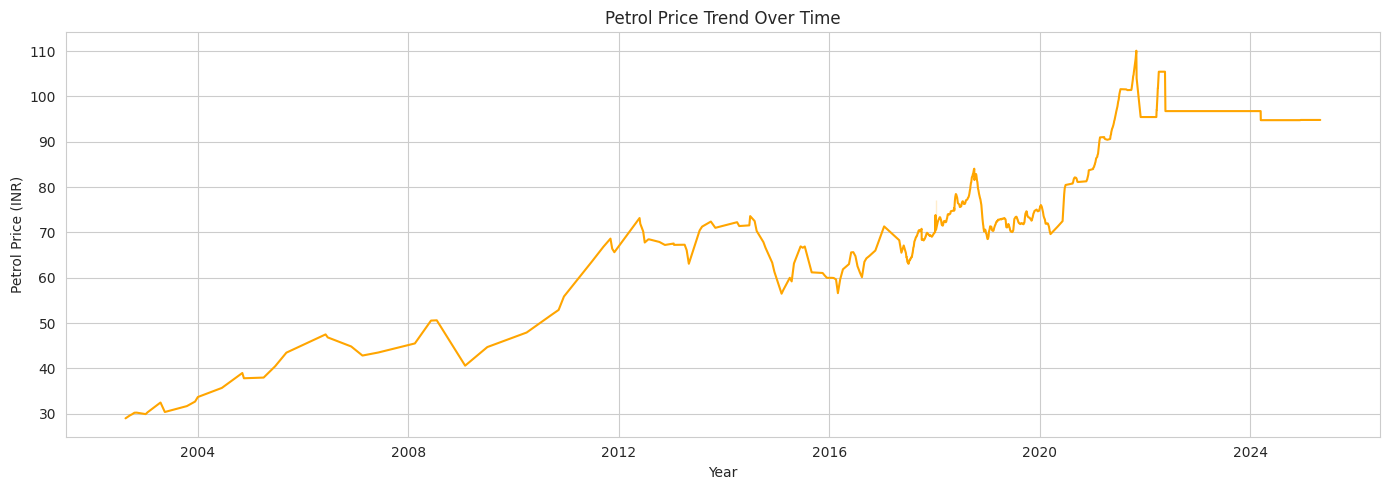

In [ ]:
#  EDA: Petrol Price Over Time
plt.figure(figsize=(14,5))
sns.lineplot(data=df, x='Date', y='Petrol_Price_INR', color='orange')
plt.title('Petrol Price Trend Over Time')
plt.ylabel('Petrol Price (INR)')
plt.xlabel('Year')
plt.tight_layout()
plt.show()

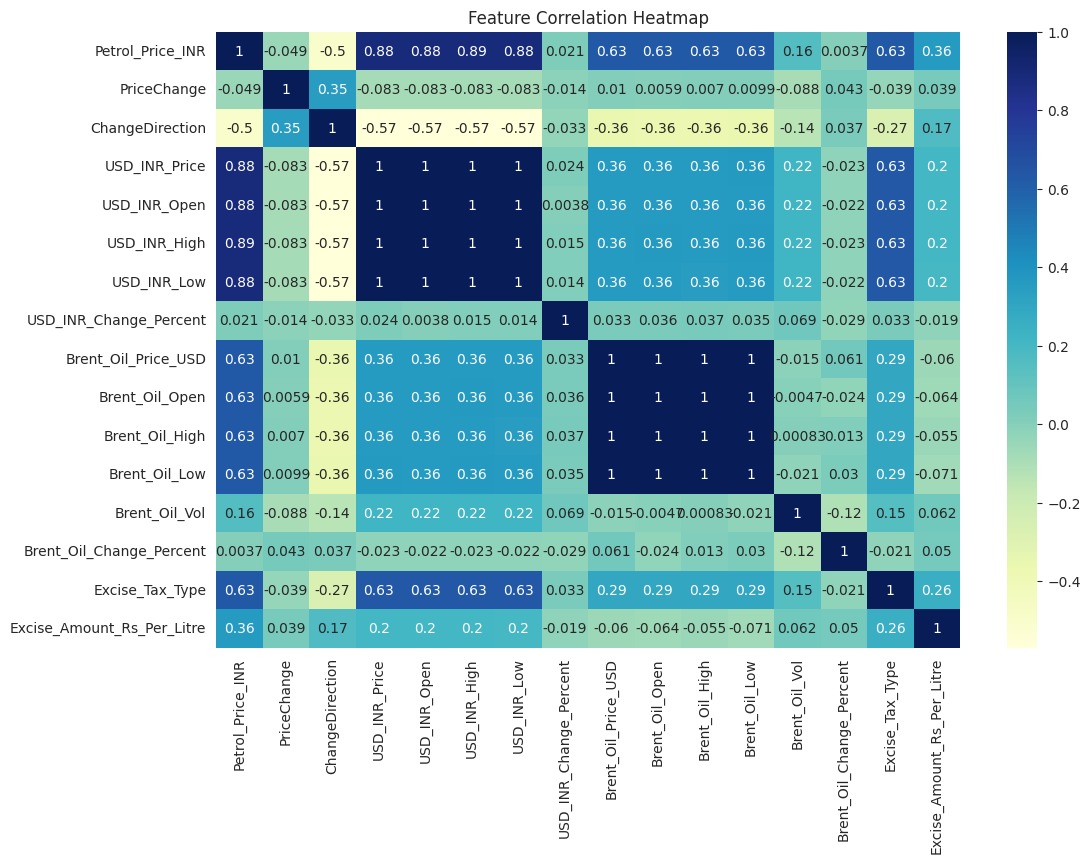

In [ ]:
# Correlation Heatmap
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='YlGnBu')
plt.title('Feature Correlation Heatmap')
plt.show()

In [ ]:
# Define Features and Target
df = df.drop(columns=['Date', 'PriceChange'])
X = df.drop('Petrol_Price_INR', axis=1)
y = df['Petrol_Price_INR']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
# Evaluation Function
def evaluate_model(model, name):
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    rmse = np.sqrt(mean_squared_error(y_test, preds))
    r2 = r2_score(y_test, preds)
    print(f"{name} → RMSE: {rmse:.2f} | R²: {r2:.2f}")
    return preds

In [ ]:
#  Train Models
lr_preds = evaluate_model(LinearRegression(), "Linear Regression")
dt_model = DecisionTreeRegressor(max_depth=5, random_state=42)
dt_preds = evaluate_model(dt_model, "Decision Tree")
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_preds = evaluate_model(rf_model, "Random Forest")
svr_preds = evaluate_model(SVR(), "Support Vector Regressor")

Linear Regression → RMSE: 2.91 | R²: 0.94
Decision Tree → RMSE: 2.09 | R²: 0.97
Random Forest → RMSE: 1.60 | R²: 0.98
Support Vector Regressor → RMSE: 14.58 | R²: -0.39


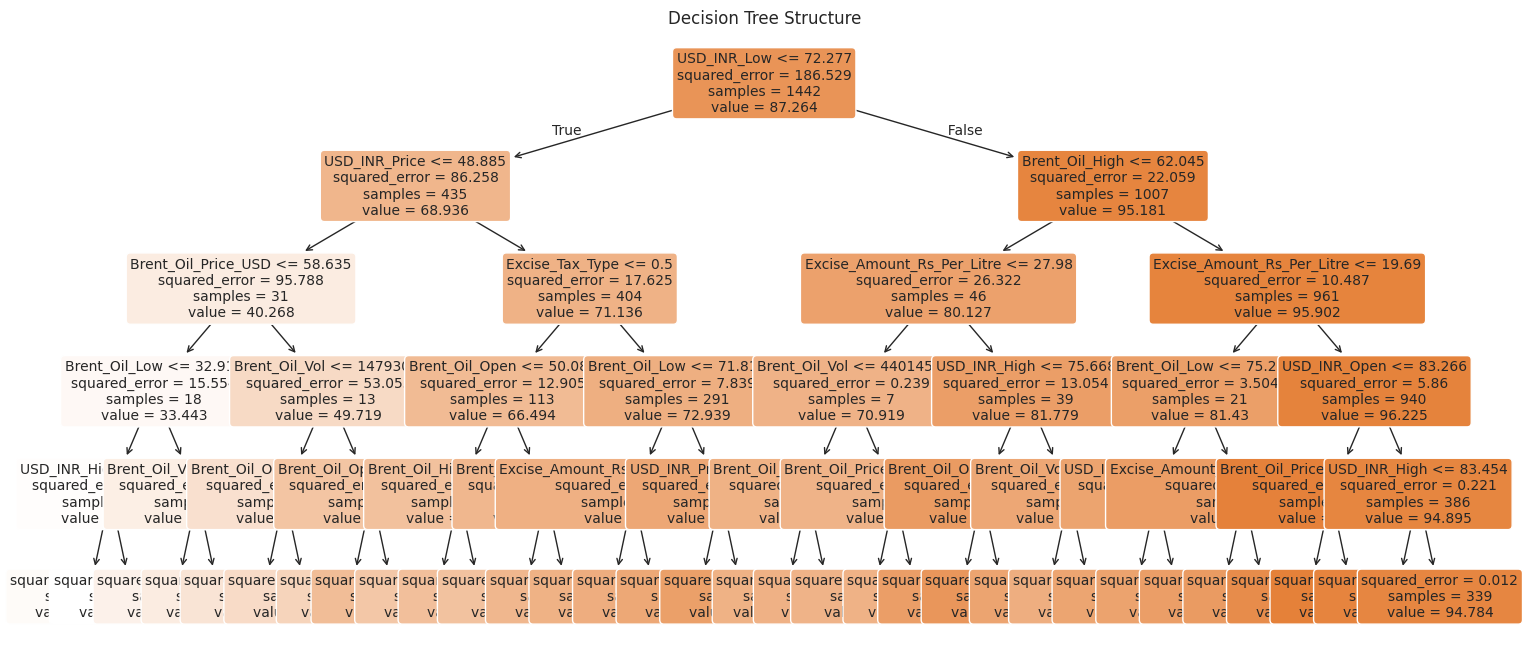

In [ ]:
# Visualize Decision Tree
plt.figure(figsize=(18, 8))
plot_tree(dt_model, feature_names=X.columns, filled=True, fontsize=10, rounded=True)
plt.title("Decision Tree Structure")
plt.show()

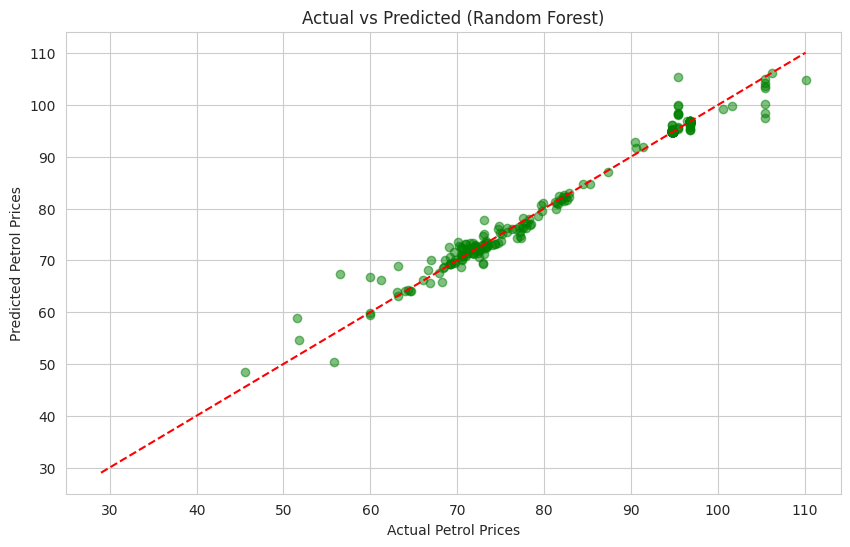

In [ ]:
# Compare Actual vs Predicted (Random Forest)
plt.figure(figsize=(10,6))
plt.scatter(y_test, rf_preds, alpha=0.5, color='green')
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--')
plt.xlabel('Actual Petrol Prices')
plt.ylabel('Predicted Petrol Prices')
plt.title('Actual vs Predicted (Random Forest)')
plt.show()

## Conclusion
- **Random Forest** showed the best accuracy.
- **Decision Trees** are interpretable and show feature importance visually.
- Petrol price is affected by Brent Oil Prices, USD-INR Rates, and Excise Tax.
- Future work: try XGBoost, add time series components, or deploy using Streamlit.